In [31]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df.shape

(10000, 14)

In [33]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [35]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [36]:
df = df.drop(["RowNumber","CustomerId","Surname"], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [37]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [38]:
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [39]:
df.groupby("Geography")["Exited"].mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [40]:
df.groupby("Gender")["Exited"].mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [41]:
df.groupby("IsActiveMember")["Exited"].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [42]:
df.groupby("HasCrCard")["Exited"].mean()

HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64

In [43]:
df.groupby("Age")["Exited"].mean()

Age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: Exited, Length: 70, dtype: float64

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

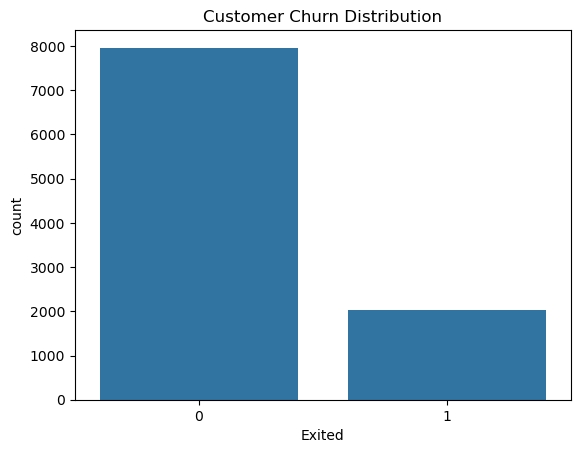

In [45]:
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

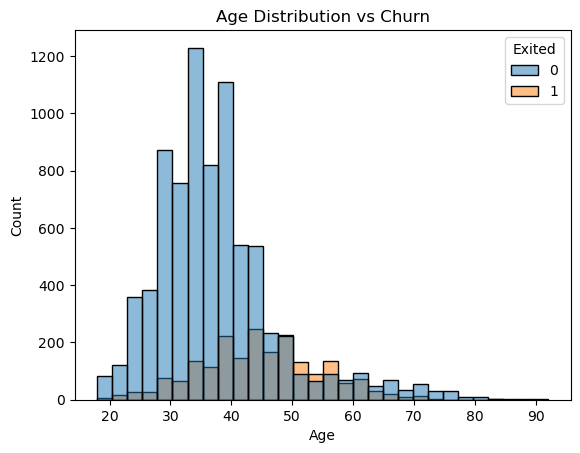

In [46]:
sns.histplot(data=df, x="Age", hue="Exited", bins=30)
plt.title("Age Distribution vs Churn")
plt.show()

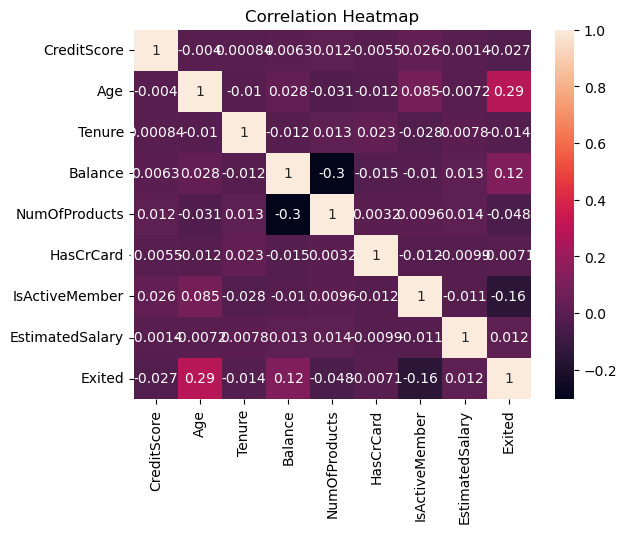

In [47]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [48]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,30,45,60,100],
    labels=["Young","Adult","MiddleAge","Senior"]
)

In [49]:
df["BalanceCategory"] = pd.cut(
    df["Balance"],
    bins=[-1,0,50000,100000,200000],
    labels=["Zero","Low","Medium","High"]
)

In [50]:
df["ActivityStatus"] = df["IsActiveMember"].map({1:"Active",0:"Inactive"})

In [51]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,ActivityStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Zero,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,High,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Zero,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,Active


In [52]:
df["AgeGroup"].head()

0    Adult
1    Adult
2    Adult
3    Adult
4    Adult
Name: AgeGroup, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'MiddleAge' < 'Senior']

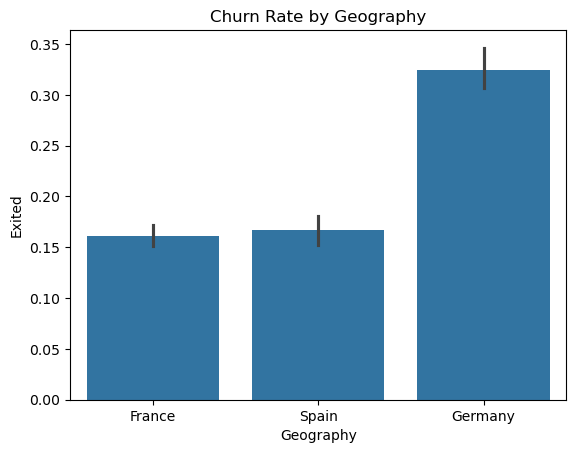

In [53]:
df.groupby("Geography")["Exited"].mean()

sns.barplot(x="Geography", y="Exited", data=df)

plt.title("Churn Rate by Geography")

plt.show()


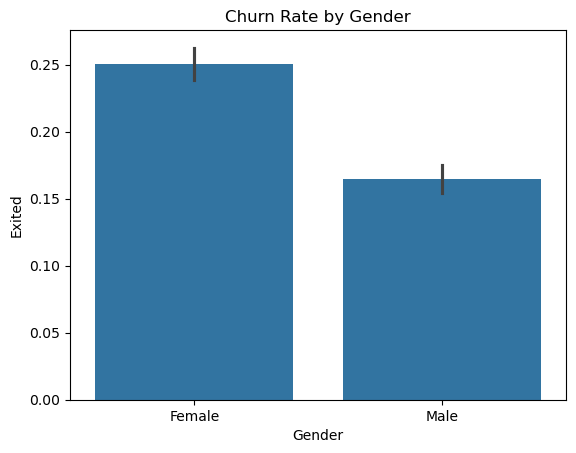

In [54]:
df.groupby("Gender")["Exited"].mean()

sns.barplot(x="Gender", y="Exited", data=df)

plt.title("Churn Rate by Gender")

plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_21960\2750792494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Exited"].mean()


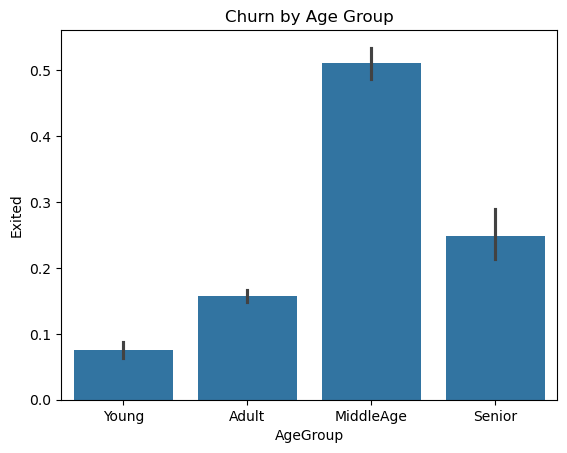

In [55]:
df.groupby("AgeGroup")["Exited"].mean()

sns.barplot(x="AgeGroup", y="Exited", data=df)

plt.title("Churn by Age Group")

plt.show()

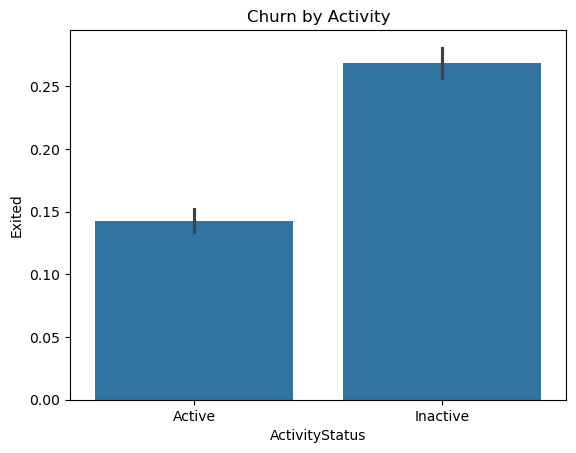

In [56]:
df.groupby("ActivityStatus")["Exited"].mean()

sns.barplot(x="ActivityStatus", y="Exited", data=df)

plt.title("Churn by Activity")

plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_21960\2794184719.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("BalanceCategory")["Exited"].mean()


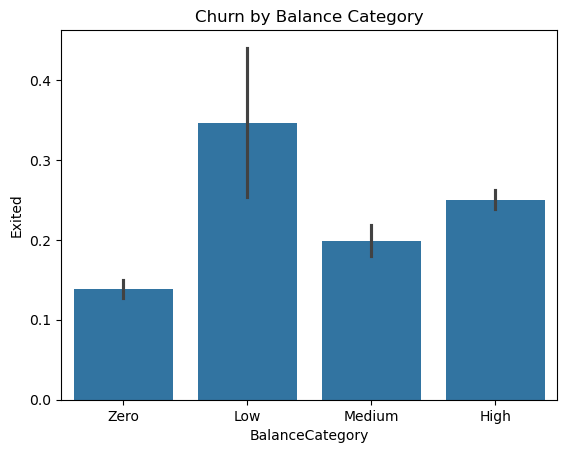

In [57]:
df.groupby("BalanceCategory")["Exited"].mean()

sns.barplot(x="BalanceCategory", y="Exited", data=df)

plt.title("Churn by Balance Category")

plt.show()

In [58]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,ActivityStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Zero,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,High,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Zero,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,Active


In [62]:
df.to_csv("bank_churn_cleaned.csv", index=False)